# The Carolina Way: UNC's Enduring Tournament Legacy


# Introduction
    
The month of March is always exciting in sports. It's the start of March Madness! D1 basketball teams across the country compete on the national stage for a chance to win the coveted NCAA D1 Men's basketball tournament. What makes it exciting are the upsets and rivalries that makes the tournament so captivating. In college basketball, the basketball rivalry that always stands out is UNC vs Duke. Personally, I'm a UNC fan as my family had relatives and even my older sister attend UNC. I would say UNC has a very good track record when it comes to March Madness with it's numerous trips to the Round of 64 all the way to the Final Four and 6 Championship Titles held. The past few years with Hubert Davis as Head Coach, the team has had its rough patches so the question I want to explore is "Will UNC qualify for the next NCAA March Madness Tournament?"

# The DataSet

The data set I chose is a file found from Kaggle: https://www.kaggle.com/datasets/andrewsundberg/college-basketball-dataset?select=cbb25.csv. Although there are team-level statistics from the past 12 years for all NCAA D1 Men's Basketball Team I wanted to focus on the team-level statistics from the most recent season, 2024-2025. 
    
From the dataset features provided below, I want to explore training a classification model to predict whether a team like UNC qualifies for the tournament or not.

### DataSet Features

    Efficiency metrics 
    ADJOE --> adjusted offensive effciency (points per 100 possessions, offense)
    ADJDE --> adjusted defnsive efficiency (point allowed per 100 possessions, defense)

    Shooting & Scoring Efficiency
    2P_O --> 2-point shooting % for *team*
    3P_O --> 3-point shooting % for a *team*


In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mb
import matplotlib.pyplot as plt



In [2]:
#Load the Dataset
unc_df = pd.read_csv("../datasets/cbb25.csv")

In [3]:
# Basic information about the dataset
print("Dataset Info: ")
unc_df.info()

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 25 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RK       364 non-null    int64  
 1   Team     364 non-null    object 
 2   CONF     364 non-null    object 
 3   G        364 non-null    int64  
 4   W        364 non-null    int64  
 5   ADJOE    364 non-null    float64
 6   ADJDE    364 non-null    float64
 7   BARTHAG  364 non-null    float64
 8   EFG_O    364 non-null    float64
 9   EFG_D    364 non-null    float64
 10  TOR      364 non-null    float64
 11  TORD     364 non-null    float64
 12  ORB      364 non-null    float64
 13  DRB      364 non-null    float64
 14  FTR      364 non-null    float64
 15  FTRD     364 non-null    float64
 16  2P_O     364 non-null    float64
 17  2P_D     364 non-null    float64
 18  3P_O     364 non-null    float64
 19  3P_D     364 non-null    float64
 20  3PR      364 non-null    float64
 21  3

# Pre Processing

#### For Step 1, I imported the libraries and Python tools I'll need 
#### For Step 2, I loaded the dataset and reads the CSV into memory as a table "unc_df"
#### For Step 3, I created a target value that makes a binary column: 1 if team has a SEED (made the tournament), 0 otherwise
#### For Step 4, I identified categorical vs numeric features to tell the pipeline which columns are categories (what conference the team is in) and which are numerical stats (ADJOE & ADJDE)
#### For Step 5, I defined my transformations: standardized numeric columns and one-hot encode conferences into dummy variables. One-hot encoding turns each conference into its own column of 0s and 1s. 
#### For Step 6, I split the data so I can train on 80% of the teams and evaluate on 20% the model hasn't seen.
#### For Step 7, I created a pipeline consisting of only the proprocessor. 


In [13]:
# ======================
# Step 1: Import Libraries
# ======================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [5]:
# ======================
# Step 2: Load the dataset
# ======================
unc_df = pd.read_csv("../datasets/cbb25.csv")


In [6]:
# ======================
# Step 3: Define target variable
# ======================
# Binary target: 1 = tournanent, 0 = non-tournament
unc_df["Tournment"] = unc_df["SEED"].notnull().astype(int)



In [7]:
# ======================
# Step 4: Identify Feature Types
# ======================
# Categorical
cat_features = ["CONF"]

# Numerical (all the other columns)
num_features = unc_df.drop(columns=["Tournment", "CONF"]).columns.tolist()

In [8]:
# ======================
# Step 5: Pre processing
# ======================
#One-hot encode categorical and numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop = "first"), cat_features)
    ]
)

In [9]:
# ======================
# Step 6: Train-test split
# ======================
X = unc_df.drop(columns = "Tournment", axis = 1)
y = unc_df["Tournment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [10]:
# ======================
# Step 7: Final preprocessed pipeline
# ======================
pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor)    
])

# Data Visualization/Understanding

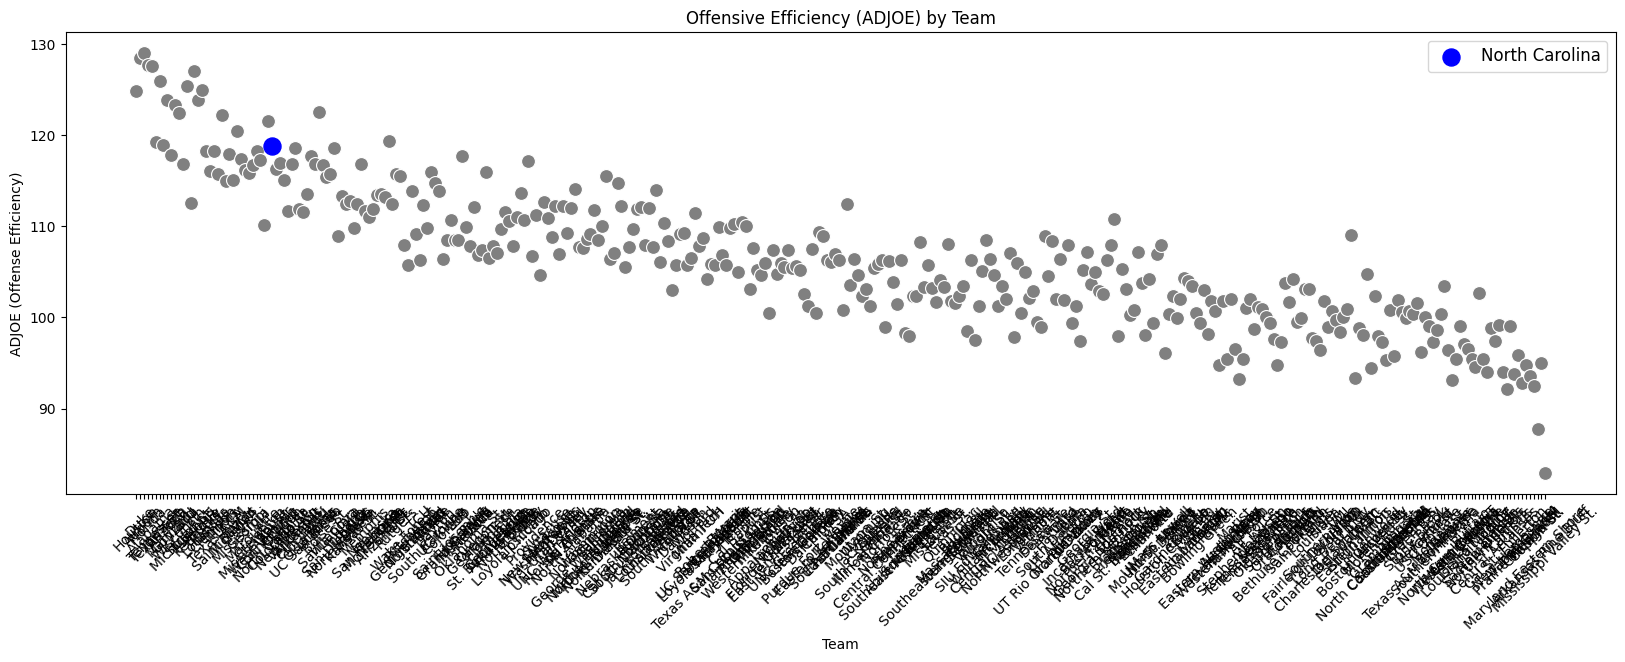

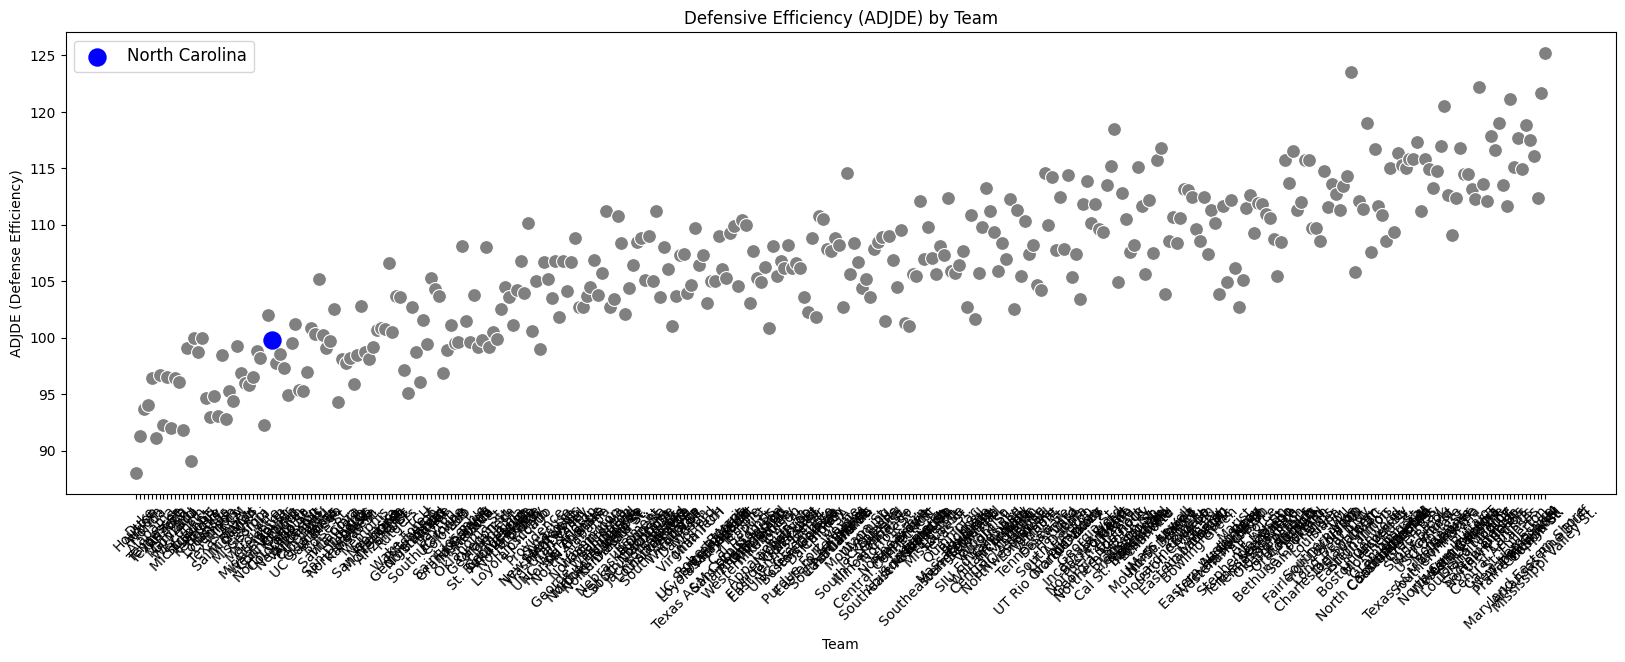

In [11]:
nc = unc_df[unc_df['Team'] == 'North Carolina']

# ==========================
# Scatterplot for ADJOE
# ==========================
plt.figure(figsize=(20,6))
sns.scatterplot(
    x ='Team', 
    y ='ADJOE', 
    data = unc_df,
    color ='grey',  #Other Teams
    s = 100
)
plt.scatter(nc['Team'], nc['ADJOE'], color='blue', s = 150, label = 'North Carolina')
plt.title('Offensive Efficiency (ADJOE) by Team')
plt.ylabel('ADJOE (Offense Efficiency)')
plt.xticks(rotation = 45)
plt.legend(fontsize = 12)
plt.show()


# ==========================
# Scatterplot for ADJDE 
# ==========================
plt.figure(figsize=(20,6))
sns.scatterplot(
    x = 'Team', 
    y = 'ADJDE', 
    data = unc_df,
    color='grey',  #Others Teams
    s =100
)
plt.scatter(nc['Team'], nc['ADJDE'], color = 'blue', s = 150, label = 'North Carolina')
plt.title('Defensive Efficiency (ADJDE) by Team')
plt.ylabel('ADJDE (Defense Efficiency)')
plt.xticks(rotation = 45)
plt.legend(fontsize = 12)
plt.show()


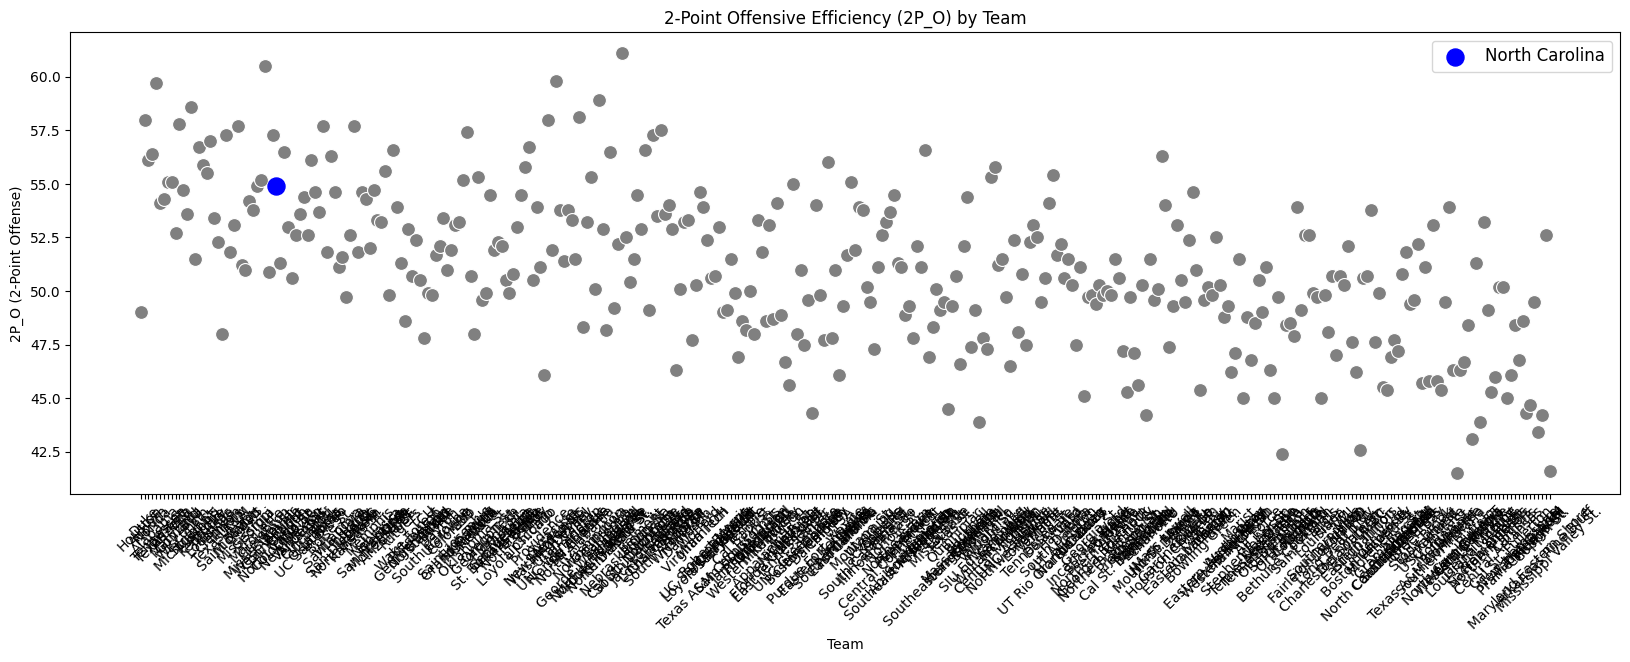

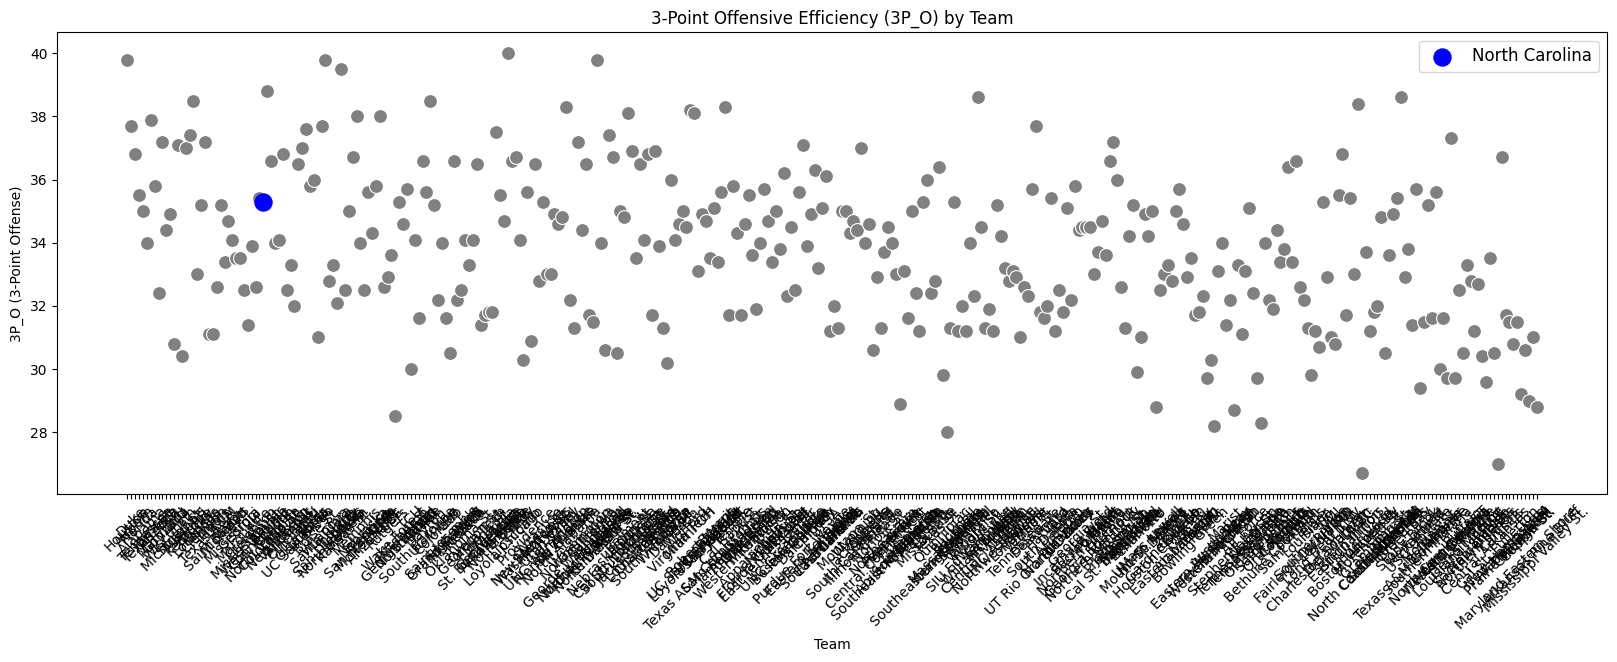

In [12]:
# ==========================
# Scatterplot for 2P_O 
# ==========================
plt.figure(figsize=(20,6))
sns.scatterplot(
    x='Team',
    y='2P_O',
    data = unc_df,
    color='grey',  # other teams
    s=100
)
plt.scatter(nc['Team'], nc['2P_O'], color='blue', s=150, label='North Carolina')
plt.title('2-Point Offensive Efficiency (2P_O) by Team')
plt.ylabel('2P_O (2-Point Offense)')
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.show()


# ==========================
#  Scatterplot for 3P_O 
# ==========================
plt.figure(figsize=(20,6))
sns.scatterplot(
    x='Team',
    y='3P_O',
    data = unc_df,
    color='grey',  # other teams
    s=100
)
plt.scatter(nc['Team'], nc['3P_O'], color='blue', s=150, label='North Carolina')
plt.title('3-Point Offensive Efficiency (3P_O) by Team')
plt.ylabel('3P_O (3-Point Offense)')
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.show()


## Data Understanding

Regarding the 2024-2025 season for UNC's Men Basketball Team:
    
When looking at the scatterplot for Offensive Efficiency (ADJOE) by Team, North Carolina is placed in the top left of the quadrant indicating that they were efficient in scoring as per 100 possessions they collectively scored close to 120 points. Then, when looking at the scatterplot for Defensive Efficiency (ADJDE) by Team, North Carolina is placed in the bottom left of the quadrant  indiciating that they were efficient in defending as per 100 posessions they collectively got scored on arouns 100 points total. 

When looking at the scatterplot for 2-Point Offensive Efficiency (2P_O) by Team, North Carolina is placed in the top left quadeant indicating that they were efficient with 2 point shooting with their percentage being around 55% compared to other teams. But, when looking at the scatterplot for 3-Point Offensive Efficiency (3P_O) by Team I was surprised that there is no linear trend compared to the other three scatterplots.

Through my data visualizations and my understanding as men's teams across NCAA D1 Baskeball are clustered in terms of offensive and defensive efficiency or shooting stats I would want to explore Decision Trees as my model as they work by finding thresholds in features that best separate the target classes. For example if ADJOE is above a certain threshold and if ADJDE is below a certain thresold is UNC a 0 or 1 (not making the tournament or making it respectively.)

    

# Modeling

Based on my classification problem, and learning all of the classification models like SVM, K-Nearest Neighbors, and Naive Bayes, Decision Tree is the model that is most appropiate for my model. By using Decision Trees, I can connect my splits to my visualizations.

A Decision Tree is a supervised machine learning algorithm that splits data into branches based on feature thresholds to classify outcomes. In my case, the outcome is whether UNC qualifies for March Madness (1) or does not qualify (0). How my Decision Tree will work is that at each split, the tree picks the stats (ADJOE, ADJDE, etc) that best separates qualifying vs non-qualifying teams. For example if UNC is above a certain threshold for their ADJOE and below a certain threshold for their ADJDE then they qualify, otherwise they don't. 

Pros of using Decision Trees for my problem is that they are easy to interpret and can create simple "if-then" rules. Additionally, when I plot the tree there is a visualization that directly shows how UNC's stats affect the outcome. On the other hand, a con to using decision tree for my problem is if my tree runs too deep overfitting may be a risk. Overfitting is when a model becomes too complex and can consequently perform poorly on new, unseen data. 

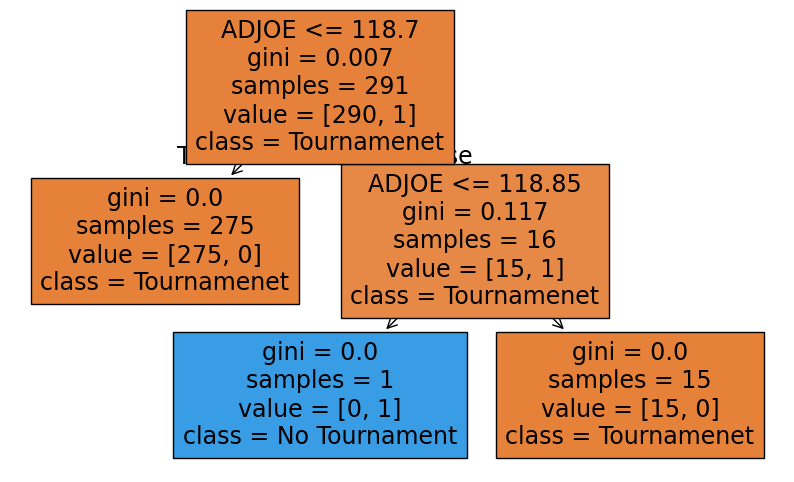

In [30]:

#Step 1: Import libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Step 2: Preparing Data
unc_df["Is_UNC"] = np.where(unc_df["Team"] == "North Carolina", 1, 0)
features = ["ADJOE", "ADJDE", "2P_O", "2P_D", "3P_O"]
X = unc_df[features]
y = unc_df["Is_UNC"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#Decision Tree Model
tree = DecisionTreeClassifier(max_depth = 3, random_state = 42)
tree.fit(X_train, y_train)

#Predcitions
y_pred = tree.predict(X_test)

#Visualize Tree
plt.figure(figsize = (10,6))
plot_tree(tree, feature_names = X.columns, class_names = ["Tournamenet", "No Tournament"], filled = True)
plt.show()

# Evaluation

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


#### Based off my accuracy, my results are "too perfect" and indicate that my evaluation isn't meaningful to the case. Unfortnately, it seems that my target variable is heavily imbalanced and that my dataset is misleading and very small. Through using ChatGPT, my test set contains only "other teams", no UNC, because we manually added UNC to the training set (since there's only 1 sample).

# Storytelling

Based on my visualizations of UNC’s 2024–2025 season stats (ADJOE, ADJDE, 2P_O, and 3P_O), it initially seemed that UNC had a strong chance of qualifying for next year’s NCAA March Madness Tournament. However, when I moved on to train and test a decision tree model, I ran into difficulties with evaluating its performance. The model produced an accuracy of 1.0, which is “too perfect” and unreliable. This happened because my dataset is heavily imbalanced, with very few examples of UNC compared to other teams. As a result, I was unable to definitively answer my initial question about UNC’s qualification through modeling alone. Nonetheless, the visualizations still provided meaningful insights into UNC’s offensive and defensive strengths relative to other teams.

# Impact Section

I was hopeful that this project can highlight how statistical analysis and modeling can predict a team whether they qualify for the March Madness Tournament or not. But through my insights I could have a positive impact on its fans as it can enchance engagement. Fans can follow statistical based predictions and analyze how their favorite team compares to others. Additionally, when it comes to filling out their March Madness bracket they can make more informed choices based on the data. On the hand, when fans become so engrossed with their prediction and get dissapointed when their team underperforms, they may grow to resent the team and reduce their enjoyment. Another negative impact for fans is they may feel the stress and anxiety to "follow the data" closely when placing bets and when they lose a bet it takes a toll on their bank account or even their mental heatlh.

